## Imports & Loads

In [190]:
CANVAS_SIZE = (130, 235) # mm (235, 130)

In [205]:
from stroke_generation import Hyperparameters, KNearest, PaletteColorsOnly
from datatypes import StrokeSequence, LoadBrush
from visualisation import visualize_stroke_sequence, show_np_image, resize_image
from visualisation import show_np_image, rotate_if_vertical
from stroke_generation import StrokeGenerationSupervisor, generate_strokes_for_layer
from stroke_generation import calculate_etf_field
from stroke_generation import k_nearest
from distance import get_distance_heatmap
from pose_estimation import detect_and_draw_animal_face_features, append_eye_center_dot_strokes
# from saliency import generate_clean_saliency

import numpy as np
from pathlib import Path
import math

from tqdm import tqdm # progress bar


# import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance
from scipy.ndimage import gaussian_filter

from scipy.ndimage import center_of_mass
from skimage.segmentation import slic, mark_boundaries

## Image Pre-loading

(235, 130, 3)


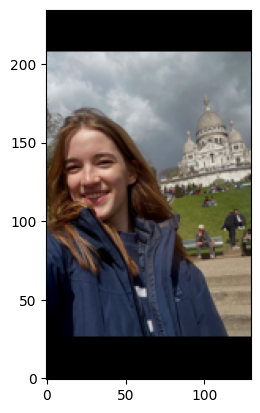

In [203]:
# 1. Load your PIL image
INPUT_PATH = Path("../images/enya.jpeg")
IMAGE_NAME = INPUT_PATH.stem
pil_original_image = Image.open(INPUT_PATH).convert("RGB").transpose(Image.FLIP_TOP_BOTTOM)

enhancer = ImageEnhance.Contrast(pil_original_image)
contrast_factor = 1.2
pil_original_image = enhancer.enhance(contrast_factor)

# 2. Resize to 440x440 (assuming resize_image is defined elsewhere)
pil_resized_image = resize_image(pil_original_image, CANVAS_SIZE)

# 3. Convert the original resized PIL image to a NumPy array (if still needed)
np_resized_image = np.array(pil_resized_image)
np_original_image = np.array(pil_original_image)

print(np_resized_image.shape)

# Display the blurred image to verify
show_np_image(np_resized_image)

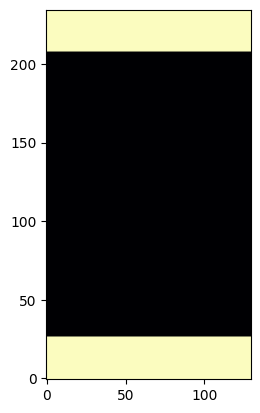

In [193]:
# 3. Create a "dummy" pure white image of the exact same original size
# This represents our "real pixels" mask BEFORE padding
mask_canvas = Image.new("L", pil_original_image.size, color=255)

# 4. Apply the exact same padding transformation to the mask canvas
# ImageOps.pad will scale and pad this mask identically to the elephant image
padded_mask_resized = ImageOps.pad(mask_canvas, CANVAS_SIZE, color=0)
np_padded_mask_resized = np.array(padded_mask_resized)

# 5. Convert mask to a 1 and 0 NumPy array
# Wherever the padded_mask is 255 (white), it's a real pixel (1). Otherwise, it's 0.
padding_mask = (np.array(padded_mask_resized) == 0).astype(np.uint8)

show_np_image(padding_mask, cmap="magma")


## Face features

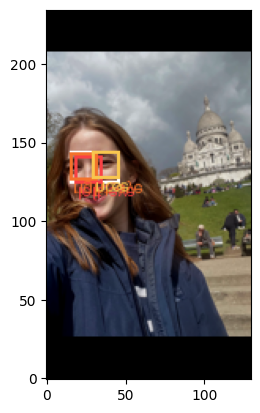

Animal 1: ['left_eye', 'right_eye', 'nose']


In [194]:
# Minimal face-feature demo: logic is implemented in pose_estimation/.
feature_overlay_pil, face_feature_detections = detect_and_draw_animal_face_features(
    np_resized_image,
    pose2d="human", # "human" or "animal"
    score_threshold=0.3,
    feature_padding=8,
    draw_face_bbox=True,
    line_width=2,
    )

show_np_image(np.array(feature_overlay_pil))
for animal_index, detection in enumerate(face_feature_detections, start=1):
    detected_names = [feature_box.name for feature_box in detection.feature_boxes]
    print(f"Animal {animal_index}: {detected_names}")

## Segmentation

(130, 235)
(235, 130, 3)


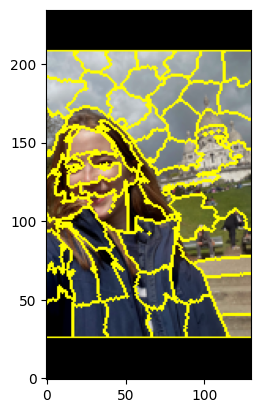

In [195]:
# 1. Run SLIC on the original image as you did
segments = slic(
    np_original_image,
    n_segments=70,
    compactness=10
)

# 2. Cast to int32 so PIL can handle it, then resize using Nearest Neighbor
segments_int32 = segments.astype(np.int32) # <--- Added this line
segments_pil = Image.fromarray(segments_int32)

resized_segments_pil = ImageOps.pad(
    segments_pil, 
    CANVAS_SIZE, 
    method=Image.Resampling.NEAREST, 
    color=0
)

print(resized_segments_pil.size)
print(np_resized_image.shape)

resized_segments = np.array(resized_segments_pil)


# 3. Calculate centroids on the NEW resized segments
for label in np.unique(resized_segments):
    # Mask out the background padding (label 0 might contain padding now)
    if label == 0: 
        continue
    centroid = center_of_mass(resized_segments == label)

show_np_image(mark_boundaries(np_resized_image, resized_segments))

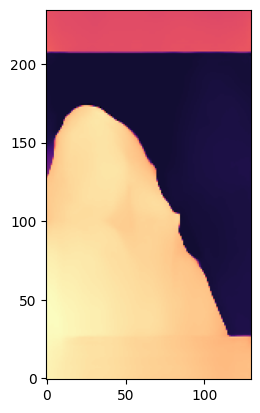

In [196]:
# blurred_saliency, img_cv = generate_clean_saliency(pil_resized_image)
depth_map = get_distance_heatmap(pil_resized_image)
show_np_image(depth_map, cmap="magma")


In [197]:
# Calculate the mean saliency per segment, excluding padded pixels.
segment_mean_saliency = []
real_pixel_mask = np_padded_mask_resized > 0

for segment_label in np.unique(resized_segments):
    if segment_label == 0:
        continue

    segment_mask = resized_segments == segment_label
    valid_segment_mask = segment_mask & real_pixel_mask

    if not np.any(valid_segment_mask):
        continue

    mean_saliency = float(depth_map[valid_segment_mask].mean())
    segment_mean_saliency.append((segment_label, mean_saliency, mean_saliency >= .5))
    # label, mean, extra_effort

segment_mean_saliency.sort(key=lambda item: item[1], reverse=True)

## Stroke Generation

Precompute the gradient

In [198]:
# Combine luminance and depth so stroke directions prefer staying on the same depth layer
if np_resized_image.ndim == 3:
    gray = 0.299 * np_resized_image[:, :, 0] + 0.587 * np_resized_image[:, :, 1] + 0.114 * np_resized_image[:, :, 2]
else:
    gray = np_resized_image.copy()

gray = gray.astype(np.float32)
depth = depth_map.astype(np.float32)

# Normalize both channels to [0, 1] before blending
gray_norm = (gray - gray.min()) / (gray.max() - gray.min() + 1e-8)
depth_norm = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)

# Higher weight means stronger depth-consistency in tangent directions
DEPTH_GUIDANCE_WEIGHT = 0.4
guidance = gray_norm + DEPTH_GUIDANCE_WEIGHT * depth_norm

# Keep gradients stable and denoise before ETF extraction
guidance_smoothed = gaussian_filter(guidance, sigma=1.5)

# ETF implementation expects image-like intensity scale for edge confidence
guidance_smoothed_u8 = np.clip(guidance_smoothed * 255.0, 0, 255).astype(np.uint8)
unit_x, unit_y = calculate_etf_field(blurred_gray=guidance_smoothed_u8)
vector_field = (unit_x, unit_y)

H, W = gray.shape

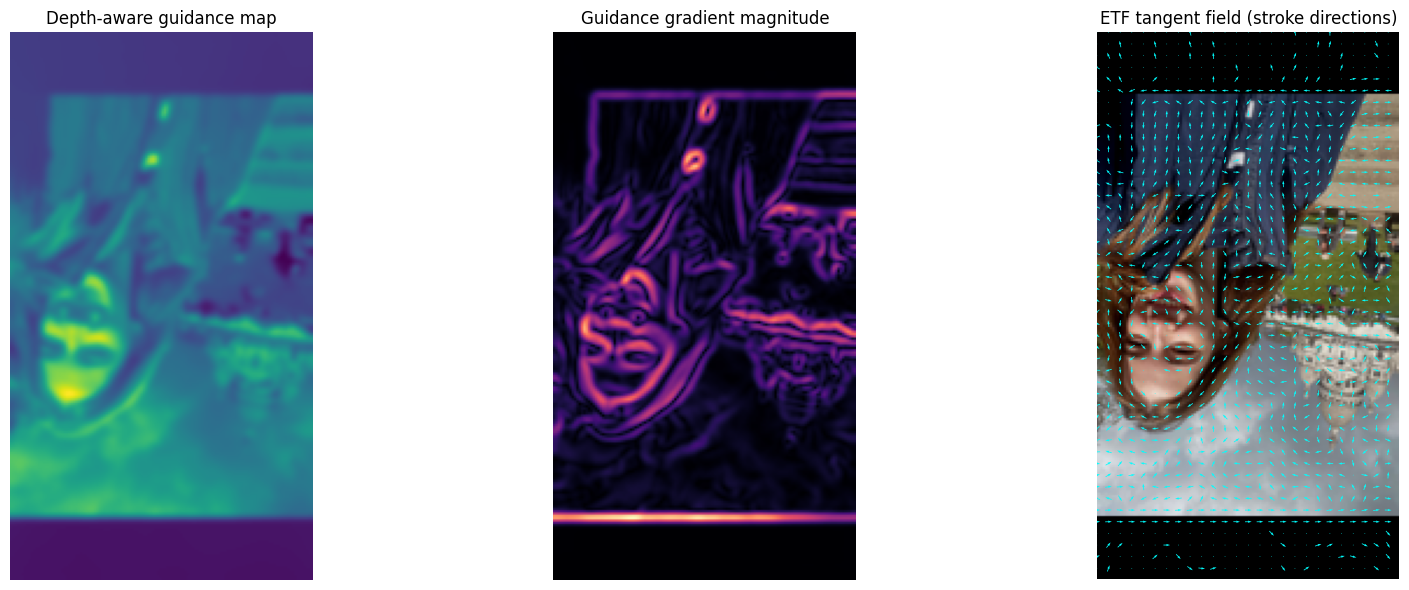

In [199]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize the generated depth-aware guidance gradient and ETF tangent field
step = 5
y_indices, x_indices = np.mgrid[0:H:step, 0:W:step]
sample_x = unit_x[::step, ::step]
sample_y = unit_y[::step, ::step]

# Gradient magnitude of the guidance map (before ETF)
gy, gx = np.gradient(guidance_smoothed)
grad_mag = np.sqrt(gx**2 + gy**2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Blended guidance map used to build the field
axes[0].imshow(guidance_smoothed, cmap="viridis")
axes[0].set_title("Depth-aware guidance map")
axes[0].axis("off")

# 2) Gradient magnitude of the guidance map
axes[1].imshow(grad_mag, cmap="magma")
axes[1].set_title("Guidance gradient magnitude")
axes[1].axis("off")

# 3) ETF vector field over the image used for strokes
axes[2].imshow(np_resized_image)
axes[2].quiver(
    x_indices,
    y_indices,
    sample_x,
    sample_y,
    color="cyan",
    angles="xy",
    scale_units="xy",
    scale=0.35,
    width=0.0025,
    pivot="mid",
)
axes[2].set_title("ETF tangent field (stroke directions)")
axes[2].set_xlim(0, W)
axes[2].set_ylim(H, 0)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
Hyperparameters.COLOR_METHOD = PaletteColorsOnly()

H, W, _ = np_resized_image.shape

stroke_sequence = StrokeSequence(image_size=(W, H))
coverage_mask = ~np_padded_mask_resized

stroke_generation_supervisor = StrokeGenerationSupervisor()

if type(Hyperparameters.COLOR_METHOD) == KNearest:
    np_k_nearest = k_nearest(
        np_resized_image,
        k=Hyperparameters.COLOR_METHOD.k
    )

    show_np_image(np_k_nearest)
else:
    np_k_nearest = None

for label, mean_saliency, extra_effort in tqdm(segment_mean_saliency):
    segment_mask = (resized_segments == label)
    if not np.any(segment_mask):
        continue

    stroke_generation_supervisor.brush_diameter = 4

    generate_strokes_for_layer(
        vector_field=vector_field,
        stroke_sequence=stroke_sequence, 
        resized_segments=resized_segments, 
        label=label, 
        extra_effort=extra_effort,
        np_image=np_resized_image,
        coverage_mask=coverage_mask,
        padding_mask=np_padded_mask_resized,
        stroke_generation_supervisor=stroke_generation_supervisor,
        np_k_nearest=np_k_nearest,
    )

100%|██████████| 50/50 [00:00<00:00, 107.40it/s]


In [201]:
# Append eye-center black dot strokes at the end of the sequence.
append_eye_center_dot_strokes(
    stroke_sequence,
    face_feature_detections,
    brush_diameter=4,
    )

2

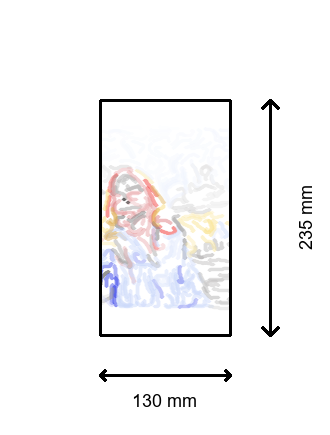

In [ ]:
visualize_stroke_sequence(stroke_sequence)

In [ ]:
# Test evaluation
# from evalutation import evaluate

# evaluate(pil_resized_image, stroke_sequence, np_padded_mask_resized)

## Stroke Reordering

In [ ]:
color_buckets = {}

queue_length = {
    "#d69927": 10,
    "#f5d049": 5,
    "#f01713": 8,
    "#0fba1a": 15,
    "#1725e6": 8,
    "#bd4bbe": 15,
    "#630d0a": 5,
    "#171515": 5,
    "#cf474d": 12,
    "#98b3f5": 6,
    "#0aa37a": 20,
    "#480ce8": 20,
}

# sort in color buckets
for stroke in stroke_sequence.strokes:
    color_key = tuple(stroke.color)
    color_buckets.setdefault(color_key, []).append(stroke)

# color buckets to queues
stroke_sequence.strokes = []
for bucket in color_buckets.values():
    bucket.sort(key=lambda stroke: stroke.pigment, reverse=True)
    max_queue_size = queue_length.get(bucket[0].hex_color, len(bucket))
    queue_count = math.ceil(len(bucket) / max(1, max_queue_size))
    bucket_queues = [[] for _ in range(queue_count)]

    for index, stroke in enumerate(bucket):
        bucket_queues[index % queue_count].append(stroke)

    # set starting value of each buckets
    for index, bucket_queue in enumerate(bucket_queues):
        bucket_queue.insert(
            0, 
            LoadBrush(
                color = bucket_queue[0].color,
                pigment = bucket_queue[0].pigment,
                deep_clean = (index == 0), # deep clean between different colors
            )
        )

    for bucket_queue in bucket_queues:
        stroke_sequence.strokes.extend(bucket_queue)

AttributeError: 'LoadBrush' object has no attribute 'hex_color'

## Stroke Statistics
We counted the reason for a stroke to be declined.
Now, we will create a graph to visualize this.

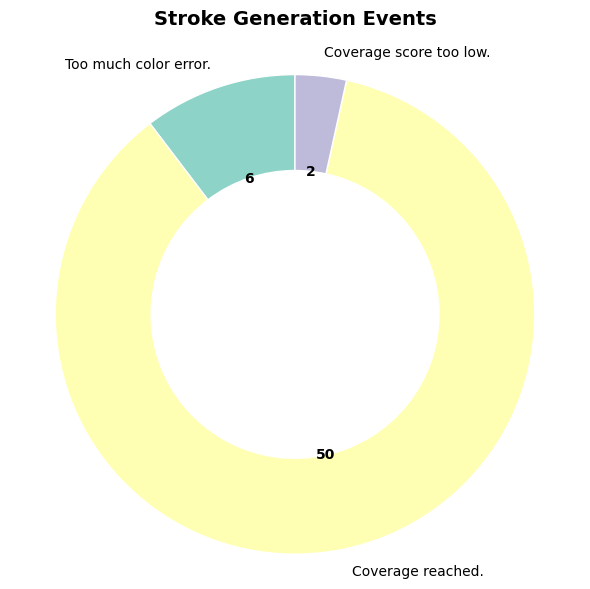

In [ ]:
stroke_generation_supervisor.plot_decline_reasons()

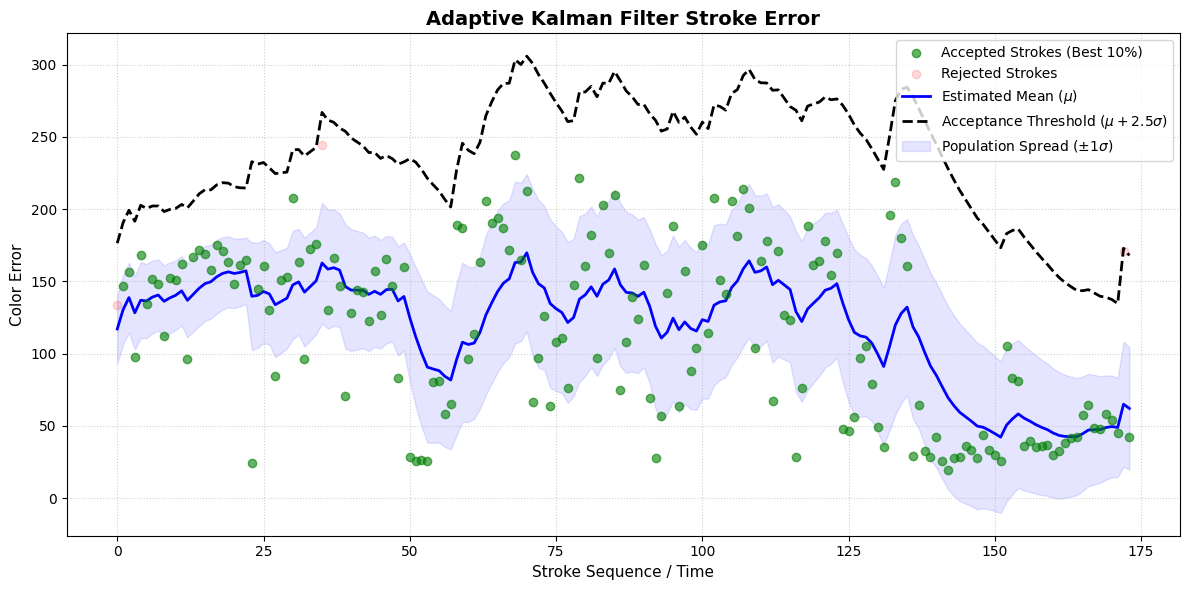

In [ ]:
stroke_generation_supervisor.plot_color_error_history()

## Visualisation

Create a video from the strokes.

In [ ]:
from visualisation import animate_stroke_sequence

animate_stroke_sequence(stroke_sequence, filename="render")

Start video rendering...


100%|██████████| 199/199 [00:01<00:00, 136.93it/s]


Save the strokes to a json file.

In [ ]:
stroke_sequence.save_to_json(Path("data/stroke_renders") / f"{IMAGE_NAME}.json")